In [1]:
#say no to warnings!
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = '3'
import tensorflow as tf
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import InputLayer, Dense
from tensorflow.keras import Sequential
from tensorflow.keras.backend import clear_session
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Exploring Sequential Neural Networks
## Iris dataset

In [3]:
data = load_iris()  

In [4]:
def get_iris_net():
    model = Sequential()
    model.add(InputLayer(input_shape=(4,)))
    model.add(Dense(32, activation="relu"))
    model.add(Dense(32, activation="relu"))
    model.add(Dense(3, activation="softmax"))
    return model

In [5]:
clear_session()
X = data["data"]
y = data["target"]
model = get_iris_net()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.33)
# check if data is evenly split
np.unique(y_train, return_counts=True), np.unique(y_test, return_counts=True)

((array([0, 1, 2]), array([33, 36, 31])),
 (array([0, 1, 2]), array([17, 14, 19])))

In [7]:
model.compile(loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [8]:
# save training logs, useful for plots
history = model.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test))

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.3300 - loss: 1.0841 - val_accuracy: 0.7200 - val_loss: 0.9109
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6900 - loss: 0.9331 - val_accuracy: 0.7200 - val_loss: 0.8209
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6400 - loss: 0.8662 - val_accuracy: 0.8600 - val_loss: 0.8205
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9400 - loss: 0.8118 - val_accuracy: 0.8200 - val_loss: 0.7855
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8900 - loss: 0.7738 - val_accuracy: 0.8600 - val_loss: 0.7499
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9000 - loss: 0.7506 - val_accuracy: 0.9800 - val_loss: 0.7091
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9300 - loss: 0.7147 - val_accuracy: 0.6400 - val_loss: 0.7333
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7200 - loss: 0.7029 - val_accuracy: 0.8600 - val_loss: 0.6289
Epoch 9

In [9]:
model.evaluate(X_train,y_train)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9400 - loss: 0.2389


[0.23893842101097107, 0.9399999976158142]

In [10]:
model.evaluate(X_test,y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9800 - loss: 0.2290


[0.22901301085948944, 0.9800000190734863]

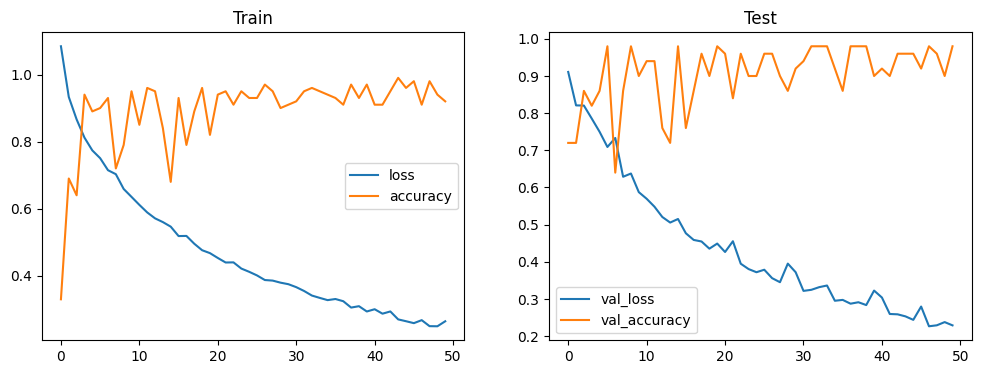

In [11]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="loss")
plt.plot(history.history["accuracy"], label="accuracy")
plt.legend()
plt.title("Train")
plt.subplot(1, 2, 2)
plt.plot(history.history["val_loss"], label="val_loss")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.legend()
plt.title("Test");

## MNIST dataset

In [12]:
(X_train, y_train), (X_test, y_test)  = tf.keras.datasets.mnist.load_data()

In [13]:
X_train.shape, X_test.shape

((60000, 28, 28), (10000, 28, 28))

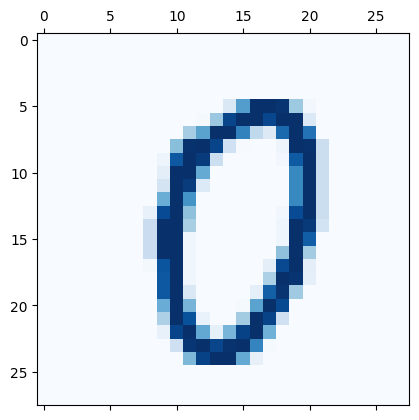

In [14]:
plt.matshow(X_train[1000], cmap="Blues");

In [15]:
y_train[1000]

np.uint8(0)

In [16]:
# flatten the images
X_train_flat = np.reshape(X_train, (60000, 28*28))
X_test_flat = np.reshape(X_test, (10000, 28*28))

# standardize the values
X_train_flat = X_train_flat.astype('float32') / 255
X_test_flat = X_test_flat.astype('float32') / 255

In [17]:
def get_mnist_net():
    model = Sequential()
    model.add(InputLayer(input_shape=(784,)))
    model.add(Dense(500, activation="relu"))
    model.add(Dense(10, activation="softmax"))
    model.compile(loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

In [21]:
clear_session()
model = get_mnist_net()

In [22]:
history = model.fit(X_train_flat, y_train, epochs=3, verbose=1, batch_size=32, validation_data=(X_test_flat, y_test))

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9392 - loss: 0.2050 - val_accuracy: 0.9652 - val_loss: 0.1151
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9746 - loss: 0.0855 - val_accuracy: 0.9769 - val_loss: 0.0808
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9826 - loss: 0.0602 - val_accuracy: 0.9774 - val_loss: 0.0806


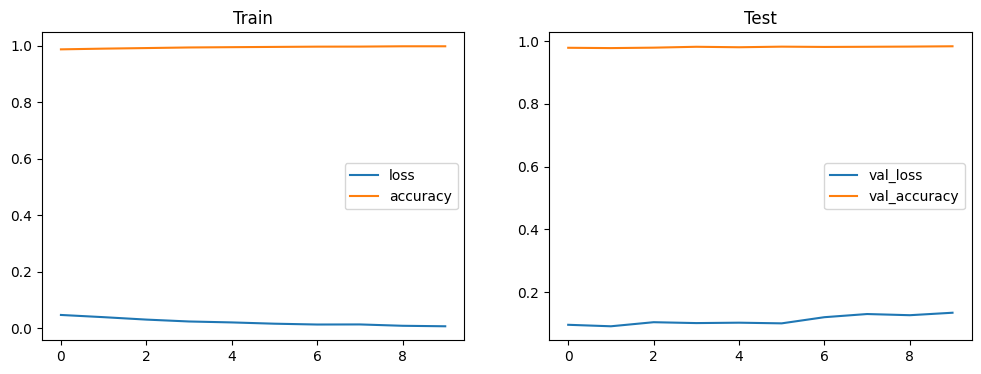

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="loss")
plt.plot(history.history["accuracy"], label="accuracy")
plt.legend()
plt.title("Train")
plt.subplot(1, 2, 2)
plt.plot(history.history["val_loss"], label="val_loss")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.legend()
plt.title("Test");